# Aubry-André Localization

**Model.** This notebook studies the single-particle Aubry-André-Harper chain with a quasiperiodic onsite potential.

**Typical uses.** Localization diagnostics, inverse-participation-ratio benchmarks, quasiperiodic potential studies, and testing eigenstate-sensitive algorithms.

**Parameters.** `n_sites` sets the number of sites $N$; `hopping` sets the hopping amplitude $t$; `potential` sets the potential strength $\lambda$; `beta` sets the irrational modulation frequency $\beta$; and `phase` sets the phase offset $\phi$. The sweep crosses the self-dual scale $\lambda/t=2$.

**Useful plots.** Mean and near-zero-state IPR versus potential strength, plus representative extended and localized site-probability profiles.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import aubry_andre_harper_chain
from quantum_lattice_models.observables import inverse_participation_ratio
from quantum_lattice_models.plotting import plot_site_probabilities
from quantum_lattice_models.spectra import eigensystem

In [2]:
n_sites = 55
strengths = np.linspace(0.0, 4.0, 33)
mean_ipr = []
midpoint_ipr = []

for strength in strengths:
    H = aubry_andre_harper_chain(
        n_sites=n_sites,
        hopping=1.0,
        potential=float(strength),
        periodic=False,
    )
    values, vectors = eigensystem(H)
    state_ipr = np.array(
        [inverse_participation_ratio(vectors[:, index]) for index in range(vectors.shape[1])]
    )
    mean_ipr.append(state_ipr.mean())
    midpoint_ipr.append(state_ipr[int(np.argmin(np.abs(values)))])

print("Aubry-Andre localization sweep")
print(f"  sites: {n_sites}")
print(f"  mean IPR at lambda=0: {mean_ipr[0]:.6f}")
print(f"  mean IPR at lambda=4: {mean_ipr[-1]:.6f}")

Aubry-Andre localization sweep
  sites: 55
  mean IPR at lambda=0: 0.026948
  mean IPR at lambda=4: 0.699123


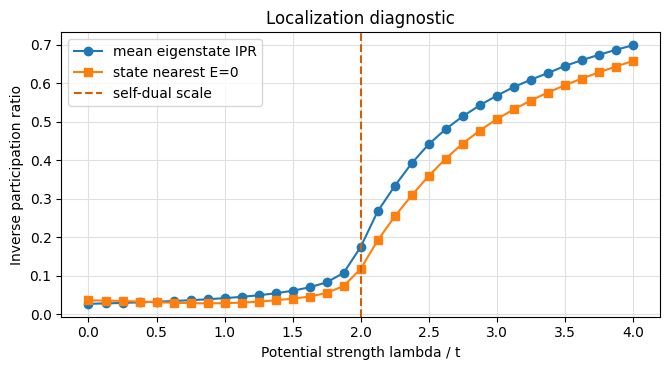

In [3]:
fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(strengths, mean_ipr, marker="o", label="mean eigenstate IPR")
ax.plot(strengths, midpoint_ipr, marker="s", label="state nearest E=0")
ax.axvline(2.0, color="#D55E00", linestyle="--", label="self-dual scale")
ax.set_xlabel("Potential strength lambda / t")
ax.set_ylabel("Inverse participation ratio")
ax.set_title("Localization diagnostic")
ax.grid(color="0.88", linewidth=0.8)
ax.legend()
fig.tight_layout()

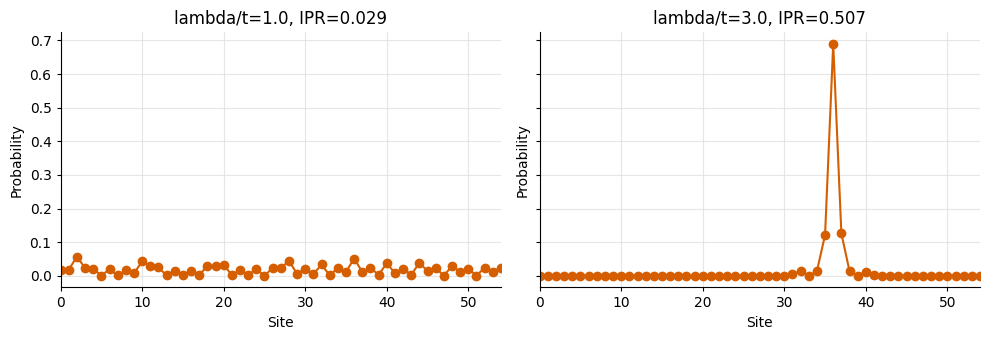

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, strength in zip(axes, [1.0, 3.0], strict=True):
    H = aubry_andre_harper_chain(n_sites=n_sites, potential=strength)
    values, vectors = eigensystem(H)
    index = int(np.argmin(np.abs(values)))
    plot_site_probabilities(
        vectors[:, index],
        ax=ax,
        title=f"lambda/t={strength:.1f}, IPR={inverse_participation_ratio(vectors[:, index]):.3f}",
    )
    ax.set_xlim(0, n_sites - 1)
fig.tight_layout()